# MOE Router Test: TabPFN

This notebook tests TabPFN as the MOE router against the calibrated Logistic Regression router. It uses only the compressed one-row-per-`group_id` router dataset, trains on hard dominant labels, evaluates probabilities against fuzzy labels, and creates basketed raw datasets only if TabPFN beats the previous ECE checkpoint.

## 0. Imports and Configuration

In [19]:
from pathlib import Path
import os
import warnings

import joblib
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold

warnings.filterwarnings('ignore')

# Must be set before any OMP-linked library (LightGBM, torch) is imported.
# Prevents the pthread_mutex_init crash caused by PyTorch and LightGBM each
# shipping their own libomp on macOS.
os.environ['OMP_NUM_THREADS'] = '1'

# ── TabPFN licence token (read from local .tabpfn_token, never committed) ────
_token_path = Path('../.tabpfn_token')
if _token_path.exists():
    os.environ['TABPFN_TOKEN'] = _token_path.read_text().strip()
else:
    print("WARNING: ../.tabpfn_token not found. TabPFN model download will fail.")
    print("Create the file with your API key from https://ux.priorlabs.ai/account")

DATA_PATH = Path('../data/processed_dataset_with_groups.csv')
TABPFN_MODEL_CACHE_DIR = Path('../tabpfn_cache')

os.environ.setdefault('TABPFN_DISABLE_TELEMETRY', '1')
os.environ.setdefault('TABPFN_MODEL_CACHE_DIR', str(TABPFN_MODEL_CACHE_DIR.resolve()))
TABPFN_MODEL_CACHE_DIR.mkdir(parents=True, exist_ok=True)

TABPFN_ROUTER_DATASET_PATH = Path('tabpfn_router_dataset_fuzzy_labels.csv')
TABPFN_OOF_PREDICTIONS_PATH = Path('tabpfn_router_oof_predictions.csv')
TABPFN_FINAL_GROUP_ASSIGNMENTS_PATH = Path('tabpfn_router_final_group_assignments.csv')
TABPFN_FINAL_MODEL_PATH = Path('tabpfn_router_final_model.joblib')

BASKET_OUTPUTS = {
    0: Path('tabpfn_basket_0_low.csv'),
    1: Path('tabpfn_basket_1_mid.csv'),
    2: Path('tabpfn_basket_2_high.csv'),
}
UNASSIGNED_OUTPUT_PATH = Path('tabpfn_basket_unassigned.csv')

RANDOM_STATE = 42
N_SPLITS = 5
N_ESTIMATORS = 8

# This is the checkpoint from the previous calibrated Logistic Regression router.
LOGISTIC_ROUTER_ECE_CHECKPOINT = 0.0759

# Same fuzzy-label settings used in the Logistic Regression router notebook.
LOW_MID_CENTER = 0.005
MID_HIGH_CENTER = 0.050
TRANSITION_WIDTH = 0.0080

ROUTING_THRESHOLD = 0.50
CLASS_NAMES = np.array(['Low', 'Mid', 'High'])

## 1. Dependency Check

This notebook uses **tabpfn v0.1.11** — the fully local version with bundled model weights.
No API key or internet connection required after installation.

Install: `pip install tabpfn==0.1.11`


In [20]:
TABPFN_AVAILABLE = True
try:
    import torch
    import tabpfn
    from tabpfn import TabPFNClassifier
    print(f'tabpfn version: {tabpfn.__version__}')
    print(f'torch  version: {torch.__version__}')
    print('TabPFN import: OK (local, no API required)')
except Exception as exc:
    TABPFN_AVAILABLE = False
    print(f'TabPFN not available: {exc}')
    print('Install with:  pip install tabpfn==0.1.11')


TabPFN not available: module 'tabpfn' has no attribute '__version__'
Install with:  pip install tabpfn==0.1.11


## 2. Local TabPFN Checkpoint Note

The first call to `.fit()` may download the TabPFN checkpoint into the local cache. If the package asks for license acceptance, complete the one-time flow and rerun the cell.

In [21]:
print('Using local TabPFNClassifier(). The checkpoint will be downloaded/loaded by TabPFN on first fit.')

Using local TabPFNClassifier(). The checkpoint will be downloaded/loaded by TabPFN on first fit.


# Phase 1: TabPFN Router Setup

## 3. Load the Processed Dataset

In [22]:
raw_df = pd.read_csv(DATA_PATH)

print(f'Raw processed rows: {len(raw_df)}')
print(f'Unique group_id values: {raw_df["group_id"].nunique()}')
raw_df.head()

Raw processed rows: 620
Unique group_id values: 276


,Fiber Volume,Length (mm),Diameter (mm),L/D,RI,Cement,Water,Sand,Fly ash C,Fly ash F,...,Geometric Fiber Eff,sigma_cu_proxy,sigma_crack_proxy,PSH Strength Index,Jb_complement,J_tip_proxy,PSH Energy Index,Second Stress,Second Strain,group_id
0,0.03,6.0,0.0379,158.31,3.48,726.88,581.50,436.13,0.0,0.0,...,16.527564,908.606239,2.399965e+00,4315.243609,4.391446e-08,2.399965e+00,2616.478657,3.948,0.0060,250
1,0.03,6.0,0.0379,158.31,3.48,714.94,571.95,428.96,0.0,0.0,...,16.527564,893.678114,2.400010e+00,4244.345466,4.464802e-08,2.400010e+00,2616.478657,2.887,0.0008,249
2,0.03,6.0,0.0379,158.31,3.48,703.38,562.70,422.03,0.0,0.0,...,16.527564,879.231239,2.399964e+00,4175.732924,4.538164e-08,2.399964e+00,2616.478657,5.024,0.0196,248
3,0.02,12.7,0.0380,334.21,4.90,1446.39,390.52,0.00,0.0,0.0,...,32.752580,6428.494366,1.000000e+08,42969.342040,1.392682e-09,1.000000e+08,10946.239762,3.180,0.0328,202
4,0.02,12.7,0.0380,334.21,4.90,1446.39,390.52,0.00,0.0,0.0,...,32.752580,6428.494366,1.000000e+08,42969.342040,1.392682e-09,1.000000e+08,10946.239762,5.899,0.0683,202


## 4. Compress to One Row per `group_id`

The TabPFN router must see only the compressed router table. Raw replicates are held back until the final basket hand-off.

In [23]:
router_df = (
    raw_df
    .groupby('group_id', as_index=False)
    .mean(numeric_only=True)
    .sort_values('group_id')
    .reset_index(drop=True)
)

print(f'Router rows after compression: {len(router_df)}')
router_df.head()

Router rows after compression: 276


,group_id,Fiber Volume,Length (mm),Diameter (mm),L/D,RI,Cement,Water,Sand,Fly ash C,...,Flaw Size Proxy,Geometric Fiber Eff,sigma_cu_proxy,sigma_crack_proxy,PSH Strength Index,Jb_complement,J_tip_proxy,PSH Energy Index,Second Stress,Second Strain
0,0,0.0,0.0,0.00,0.0,0.0,375.00,318.00,435.00,0.00,...,1.080985,0.0,1412.735796,0.925082,0.0,1.000000e+08,0.925082,0.0,4.750,0.027500
1,1,0.0,0.0,0.00,0.0,0.0,558.00,326.00,446.00,0.00,...,1.080912,0.0,2100.202375,0.925145,0.0,1.000000e+08,0.925145,0.0,5.500,0.015900
2,2,0.0,0.0,0.00,0.0,0.0,586.32,152.44,469.06,703.59,...,2.751808,0.0,4961.296033,0.363397,0.0,1.000000e+08,0.363397,0.0,1.149,0.000000
3,3,0.0,12.0,0.04,300.0,0.0,315.00,168.00,760.00,0.00,...,7.823129,0.0,787.499980,0.127826,0.0,1.410935e-08,0.127826,0.0,4.090,0.000140
4,4,0.0,12.0,0.04,300.0,0.0,400.00,166.40,750.00,0.00,...,8.103875,0.0,1249.999961,0.123398,0.0,8.888889e-09,0.123398,0.0,4.870,0.000135


## 5. Rebuild Fuzzy Labels and Extract the Dominant Class

TabPFN trains on the hard `dominant_class_id`, but its probabilities are still scored against the fuzzy label distribution.

In [24]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))


def fuzzy_strain_probabilities(
    strain_values,
    low_mid_center=LOW_MID_CENTER,
    mid_high_center=MID_HIGH_CENTER,
    transition_width=TRANSITION_WIDTH,
):
    strain_values = np.asarray(strain_values, dtype=float)

    above_low_mid = sigmoid((strain_values - low_mid_center) / transition_width)
    above_mid_high = sigmoid((strain_values - mid_high_center) / transition_width)

    p_low = 1.0 - above_low_mid
    p_mid = above_low_mid - above_mid_high
    p_high = above_mid_high

    probabilities = np.column_stack([p_low, p_mid, p_high])
    probabilities = np.clip(probabilities, 0.0, 1.0)
    probabilities = probabilities / probabilities.sum(axis=1, keepdims=True)
    return probabilities


fuzzy_probs = fuzzy_strain_probabilities(router_df['Second Strain'])

router_df['prob_low'] = fuzzy_probs[:, 0]
router_df['prob_mid'] = fuzzy_probs[:, 1]
router_df['prob_high'] = fuzzy_probs[:, 2]
router_df['dominant_class_id'] = fuzzy_probs.argmax(axis=1)
router_df['dominant_class'] = CLASS_NAMES[router_df['dominant_class_id']]

router_df.to_csv(TABPFN_ROUTER_DATASET_PATH, index=False)

print('Dominant class distribution:')
print(router_df['dominant_class'].value_counts().reindex(CLASS_NAMES, fill_value=0))
print(f'\nSaved TabPFN router dataset to: {TABPFN_ROUTER_DATASET_PATH.resolve()}')

router_df[['group_id', 'Second Strain', 'prob_low', 'prob_mid', 'prob_high', 'dominant_class']].head(10)

Dominant class distribution:
dominant_class
Low      71
Mid     183
High     22
Name: count, dtype: int64

Saved TabPFN router dataset to: /Users/adityagk/Desktop/projects/ECC/other_implementations/tabpfn_router_dataset_fuzzy_labels.csv


,group_id,Second Strain,prob_low,prob_mid,prob_high,dominant_class
0,0,0.027500,0.056652,0.886695,0.056652,Mid
1,1,0.015900,0.203834,0.782274,0.013891,Mid
2,2,0.000000,0.651355,0.346718,0.001927,Low
3,3,0.000140,0.647370,0.350669,0.001961,Low
4,4,0.000135,0.647513,0.350528,0.001959,Low
5,5,0.000138,0.647427,0.350612,0.001960,Low
6,6,0.000145,0.647228,0.350810,0.001962,Low
7,7,0.000141,0.647342,0.350697,0.001961,Low
8,8,0.000144,0.647256,0.350782,0.001962,Low
9,9,0.000157,0.646885,0.351150,0.001965,Low


## 6. Select Router Features

`Second Stress` and `Second Strain` are excluded from training features because `Second Strain` created the labels and `Second Stress` is a measured target.

In [25]:
target_columns = [
    'Second Stress',
    'Second Strain',
    'prob_low',
    'prob_mid',
    'prob_high',
    'dominant_class_id',
    'dominant_class',
]

feature_columns = [
    col for col in router_df.columns
    if col not in target_columns + ['group_id']
]

X = router_df[feature_columns]
y = router_df['dominant_class_id'].to_numpy()
soft_y = router_df[['prob_low', 'prob_mid', 'prob_high']].to_numpy()
groups = router_df['group_id'].to_numpy()

print(f'Router rows: {len(router_df)}')
print(f'Router features: {len(feature_columns)}')
feature_columns

Router rows: 276
Router features: 37


['Fiber Volume',
 'Length (mm)',
 'Diameter (mm)',
 'L/D',
 'RI',
 'Cement',
 'Water',
 'Sand',
 'Fly ash C',
 'Fly ash F',
 'GGBS',
 'Coarse Aggr.',
 'Silica Fume',
 'Water Reducer/SP',
 'Fiber',
 'C/B',
 'W/C',
 'W/B',
 'FA/Binder Ratio',
 'S/B Ratio',
 'Paste Volume',
 'SCM Ratio',
 'Aggregate Ratio',
 'Fiber Surface Area',
 'Fiber Efficiency',
 'GGBS Presence',
 'Silica Fume Presence',
 'Coarse Aggr Presence',
 'tau_proxy',
 'Flaw Size Proxy',
 'Geometric Fiber Eff',
 'sigma_cu_proxy',
 'sigma_crack_proxy',
 'PSH Strength Index',
 'Jb_complement',
 'J_tip_proxy',
 'PSH Energy Index']

# Phase 2: Scoring TabPFN

## 7. Metric Helpers

In [26]:
def hard_label_brier_score(y_true, predicted_probabilities, n_classes=3):
    y_one_hot = np.eye(n_classes)[np.asarray(y_true, dtype=int)]
    return np.mean(np.sum((predicted_probabilities - y_one_hot) ** 2, axis=1))


def soft_label_brier_score(soft_targets, predicted_probabilities):
    return np.mean(np.sum((predicted_probabilities - soft_targets) ** 2, axis=1))


def expected_calibration_error(y_true, predicted_probabilities, n_bins=10):
    y_true = np.asarray(y_true, dtype=int)
    predicted_probabilities = np.asarray(predicted_probabilities, dtype=float)

    confidences = predicted_probabilities.max(axis=1)
    predictions = predicted_probabilities.argmax(axis=1)
    correctness = (predictions == y_true).astype(float)

    ece = 0.0
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)

    for bin_idx in range(n_bins):
        lower = bin_edges[bin_idx]
        upper = bin_edges[bin_idx + 1]
        if bin_idx == 0:
            in_bin = (confidences >= lower) & (confidences <= upper)
        else:
            in_bin = (confidences > lower) & (confidences <= upper)

        if not np.any(in_bin):
            continue

        bin_weight = in_bin.mean()
        bin_accuracy = correctness[in_bin].mean()
        bin_confidence = confidences[in_bin].mean()
        ece += bin_weight * abs(bin_accuracy - bin_confidence)

    return ece

## 8. TabPFN Model Factory

In [27]:
def make_tabpfn_router():
    import inspect
    params = inspect.signature(TabPFNClassifier.__init__).parameters
    # v0.1.x local API
    if 'N_ensemble_configurations' in params:
        return TabPFNClassifier(N_ensemble_configurations=N_ESTIMATORS, seed=RANDOM_STATE)
    # v2+ / v8+ API (no auth params here — handled at import time)
    if 'n_estimators' in params:
        return TabPFNClassifier(n_estimators=N_ESTIMATORS, random_state=RANDOM_STATE)
    # fallback: use all defaults
    return TabPFNClassifier()


## 9. 5-Fold GroupKFold Cross-Validation

TabPFN is trained on hard dominant classes. Its predicted probabilities are then compared against both the hard dominant class and the fuzzy label distribution.

In [28]:
gkf = GroupKFold(n_splits=N_SPLITS)

oof_probabilities = np.zeros((len(router_df), len(CLASS_NAMES)))
fold_rows = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=groups), start=1):
    model = make_tabpfn_router()
    model.fit(X.iloc[train_idx], y[train_idx])

    fold_probabilities = model.predict_proba(X.iloc[test_idx])

    aligned_probabilities = np.zeros((len(test_idx), len(CLASS_NAMES)))
    for class_position, class_id in enumerate(model.classes_):
        aligned_probabilities[:, int(class_id)] = fold_probabilities[:, class_position]

    oof_probabilities[test_idx] = aligned_probabilities

    fold_rows.append({
        'fold': fold,
        'train_rows': len(train_idx),
        'test_rows': len(test_idx),
        'hard_label_brier_score': hard_label_brier_score(y[test_idx], aligned_probabilities),
        'soft_label_brier_score': soft_label_brier_score(soft_y[test_idx], aligned_probabilities),
        'ece': expected_calibration_error(y[test_idx], aligned_probabilities),
    })

fold_metrics = pd.DataFrame(fold_rows)
fold_metrics

/Users/adityagk/miniconda3/lib/python3.12/site-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/Users/adityagk/miniconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/adityagk/miniconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/adityagk/miniconda3/lib/python3.12/site-packages/torch/_dynamo/e

,fold,train_rows,test_rows,hard_label_brier_score,soft_label_brier_score,ece
0,1,220,56,0.210361,0.214742,0.084190
1,2,221,55,0.171780,0.187917,0.089730
2,3,221,55,0.174483,0.168982,0.037729
3,4,221,55,0.196314,0.206480,0.058033
4,5,221,55,0.277099,0.215937,0.132720


## 10. Checkpoint: TabPFN vs Logistic Regression

In [29]:
overall_metrics = {
    'hard_label_brier_score': hard_label_brier_score(y, oof_probabilities),
    'soft_label_brier_score': soft_label_brier_score(soft_y, oof_probabilities),
    'ece': expected_calibration_error(y, oof_probabilities),
    'logistic_router_ece_checkpoint': LOGISTIC_ROUTER_ECE_CHECKPOINT,
}

overall_metrics_df = pd.DataFrame([overall_metrics])
display(overall_metrics_df)

TABPFN_IS_WINNER = overall_metrics['ece'] < LOGISTIC_ROUTER_ECE_CHECKPOINT

if TABPFN_IS_WINNER:
    print(
        f'PASS: TabPFN ECE = {overall_metrics["ece"]:.4f} is lower than '
        f'{LOGISTIC_ROUTER_ECE_CHECKPOINT:.4f}. TabPFN becomes the router.'
    )
else:
    print(
        f'REJECT: TabPFN ECE = {overall_metrics["ece"]:.4f} is not lower than '
        f'{LOGISTIC_ROUTER_ECE_CHECKPOINT:.4f}. Keep the Logistic Regression router.'
    )

,hard_label_brier_score,soft_label_brier_score,ece,logistic_router_ece_checkpoint
0,0.206023,0.19887,0.060546,0.0759


PASS: TabPFN ECE = 0.0605 is lower than 0.0759. TabPFN becomes the router.


## 11. Save Out-of-Fold Predictions

In [30]:
oof_df = router_df[['group_id', 'dominant_class', 'dominant_class_id']].copy()
oof_df['true_prob_low'] = router_df['prob_low']
oof_df['true_prob_mid'] = router_df['prob_mid']
oof_df['true_prob_high'] = router_df['prob_high']
oof_df['pred_prob_low'] = oof_probabilities[:, 0]
oof_df['pred_prob_mid'] = oof_probabilities[:, 1]
oof_df['pred_prob_high'] = oof_probabilities[:, 2]
oof_df['predicted_class_id'] = oof_probabilities.argmax(axis=1)
oof_df['predicted_class'] = CLASS_NAMES[oof_df['predicted_class_id']]

oof_df.to_csv(TABPFN_OOF_PREDICTIONS_PATH, index=False)
print(f'Saved TabPFN out-of-fold predictions to: {TABPFN_OOF_PREDICTIONS_PATH.resolve()}')
oof_df.head()

Saved TabPFN out-of-fold predictions to: /Users/adityagk/Desktop/projects/ECC/other_implementations/tabpfn_router_oof_predictions.csv


,group_id,dominant_class,dominant_class_id,true_prob_low,true_prob_mid,true_prob_high,pred_prob_low,pred_prob_mid,pred_prob_high,predicted_class_id,predicted_class
0,0,Mid,1,0.056652,0.886695,0.056652,0.084945,0.902288,0.012767,1,Mid
1,1,Mid,1,0.203834,0.782274,0.013891,0.203868,0.789483,0.006648,1,Mid
2,2,Low,0,0.651355,0.346718,0.001927,0.136902,0.834264,0.028835,1,Mid
3,3,Low,0,0.647370,0.350669,0.001961,0.999562,0.000430,0.000008,0,Low
4,4,Low,0,0.647513,0.350528,0.001959,0.999793,0.000202,0.000005,0,Low


# Phase 3: Slicing the Data

## 12. Fit Final TabPFN Router on All Groups

This cell only runs if TabPFN beats the Logistic Regression ECE checkpoint.

In [31]:
if not TABPFN_IS_WINNER:
    final_router_model = None
    final_group_probabilities = None
    print('Skipping final TabPFN routing because TabPFN did not beat the checkpoint.')
else:
    final_router_model = make_tabpfn_router()
    final_router_model.fit(X, y)

    raw_final_probabilities = final_router_model.predict_proba(X)
    final_group_probabilities = np.zeros((len(router_df), len(CLASS_NAMES)))
    for class_position, class_id in enumerate(final_router_model.classes_):
        final_group_probabilities[:, int(class_id)] = raw_final_probabilities[:, class_position]

    joblib.dump(
        {
            'model': final_router_model,
            'feature_columns': feature_columns,
            'class_names': CLASS_NAMES.tolist(),
            'overall_metrics': overall_metrics,
            'routing_threshold': ROUTING_THRESHOLD,
        },
        TABPFN_FINAL_MODEL_PATH,
    )

    print(f'Saved final TabPFN router model to: {TABPFN_FINAL_MODEL_PATH.resolve()}')

/Users/adityagk/miniconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/adityagk/miniconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/adityagk/miniconda3/lib/python3.12/site-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Saved final TabPFN router model to: /Users/adityagk/Desktop/projects/ECC/other_implementations/tabpfn_router_final_model.joblib


## 13. Assign Groups to Baskets with the 50% Rule

A group is assigned to Basket 0, 1, or 2 only when that class probability is strictly above `0.50`. If no class clears the threshold, the group is marked `Unassigned` for inspection.

In [32]:
if not TABPFN_IS_WINNER:
    final_assignments = None
    print('No TabPFN assignments created because TabPFN did not beat the checkpoint.')
else:
    final_assignments = router_df[['group_id', 'dominant_class', 'dominant_class_id']].copy()
    final_assignments['final_prob_low'] = final_group_probabilities[:, 0]
    final_assignments['final_prob_mid'] = final_group_probabilities[:, 1]
    final_assignments['final_prob_high'] = final_group_probabilities[:, 2]
    final_assignments['max_probability'] = final_group_probabilities.max(axis=1)
    # Prioritized threshold logic
    expert_assignments = []
    for probs in final_group_probabilities:
        prob_low, prob_mid, prob_high = probs[0], probs[1], probs[2]
        
        # Priority 1: Catch the High-Strain outliers!
        if prob_high > 0.25:  
            expert_assignments.append(2)
        # Priority 2: Catch the Brittle outliers
        elif prob_low > 0.35:
            expert_assignments.append(0)
        # Default: Send to the Bulk/Mid Expert
        else:
            expert_assignments.append(1)
            
    final_assignments['basket_id'] = expert_assignments
    final_assignments['basket_name'] = np.where(
        final_assignments['basket_id'] == -1,
        'Unassigned',
        CLASS_NAMES[final_assignments['basket_id'].clip(lower=0)],
    )

    final_assignments.to_csv(TABPFN_FINAL_GROUP_ASSIGNMENTS_PATH, index=False)

    print('Final group assignment counts:')
    print(final_assignments['basket_name'].value_counts())
    print(f'\nSaved final group assignments to: {TABPFN_FINAL_GROUP_ASSIGNMENTS_PATH.resolve()}')

    final_assignments.head()

Final group assignment counts:
basket_name
Mid     179
Low      69
High     28
Name: count, dtype: int64

Saved final group assignments to: /Users/adityagk/Desktop/projects/ECC/other_implementations/tabpfn_router_final_group_assignments.csv


## 14. Hand Off Basket Assignments to the Raw Replicate Rows

Every raw row inherits its group's basket. This keeps all replicates from the same concrete mix together.

In [33]:
if not TABPFN_IS_WINNER:
    routed_raw_df = None
    print('No basket CSVs created because TabPFN did not beat the checkpoint.')
else:
    routed_raw_df = raw_df.merge(
        final_assignments[
            [
                'group_id',
                'basket_id',
                'basket_name',
                'final_prob_low',
                'final_prob_mid',
                'final_prob_high',
                'max_probability',
            ]
        ],
        on='group_id',
        how='left',
        validate='many_to_one',
    )

    for basket_id, output_path in BASKET_OUTPUTS.items():
        basket_df = routed_raw_df[routed_raw_df['basket_id'] == basket_id].copy()
        basket_df.to_csv(output_path, index=False)
        print(f'Basket {basket_id} ({CLASS_NAMES[basket_id]}): {len(basket_df)} rows -> {output_path.resolve()}')

    unassigned_df = routed_raw_df[routed_raw_df['basket_id'] == -1].copy()
    if len(unassigned_df) > 0:
        unassigned_df.to_csv(UNASSIGNED_OUTPUT_PATH, index=False)
        print(f'Unassigned: {len(unassigned_df)} rows -> {UNASSIGNED_OUTPUT_PATH.resolve()}')
    else:
        print('Unassigned: 0 rows')

    routed_raw_df.groupby('basket_name').size().rename('raw_rows')

Basket 0 (Low): 89 rows -> /Users/adityagk/Desktop/projects/ECC/other_implementations/tabpfn_basket_0_low.csv
Basket 1 (Mid): 474 rows -> /Users/adityagk/Desktop/projects/ECC/other_implementations/tabpfn_basket_1_mid.csv
Basket 2 (High): 57 rows -> /Users/adityagk/Desktop/projects/ECC/other_implementations/tabpfn_basket_2_high.csv
Unassigned: 0 rows


# Phase 4: Training the Three Experts

Objective: Train models specifically suited to the physical reality of each region using **Soft Data Weighting**.
- All three experts are trained on the **entire** training dataset.
- The trick: each expert's `sample_weight` = `inverse_variance_weight × TabPFN_prob_for_that_class`.
  - This teaches the expert to focus on its region without hard data boundaries that starve small baskets or contaminate data.
- **Expert 0 (Low / NoPSH)**: `LGBMRegressor` — handles boolean flags and brittle data (`num_leaves=15`, `min_child_samples=5`).
- **Expert 1 (Mid / Bulk)**: `LGBMRegressor` — heavier regularisation for the large, dense mid-region.
- **Expert 2 (High / PSH)**: `GradientBoostingRegressor` + `PowerTransformer` — robust to the sparse high-strain tail.

In [34]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import PowerTransformer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import HuberRegressor, QuantileRegressor
from lightgbm import LGBMRegressor
from ngboost import NGBRegressor

# Calculate Inverse Variance Weighting
group_variances = raw_df.groupby('group_id')['Second Strain'].var().fillna(0)
raw_df['group_variance'] = raw_df['group_id'].map(group_variances)
raw_df['sample_weight'] = 1.0 / (raw_df['group_variance'] + 0.1)

print("Sample weights calculated based on Inverse Variance Weighting.")

Sample weights calculated based on Inverse Variance Weighting.


# Phase 5: Pipeline Evaluation (Out-of-Fold Testing)

Objective: Calculate the global error of the pipeline without suffering from data leakage. We test the entire living pipeline with a 5-Fold GroupKFold loop.

In [35]:
# ── Experiment toggle ──────────────────────────────────────────────────────────
# Set USE_SVR_HIGH = False to revert Expert 2 back to the original GBR approach.
USE_SVR_HIGH     = True

# log1p-transformed copies of these columns are appended to Expert 2's feature
# matrix to help the linear model capture the nonlinear PSH tail behaviour.
HIGH_LOG_COLS    = ['PSH Strength Index', 'PSH Energy Index', 'Fiber Efficiency']

# Raise routing probabilities to this power before renormalising.
# BLEND_SHARPENING > 1 concentrates blend weight on whichever expert has the
# highest routing probability — reduces Mid-expert dilution of extreme tail.
BLEND_SHARPENING = 2.0


class NGBQuantilePredictor:
    """NGBRegressor → quantile predictions. Pass yj_transformer=None for no target transform."""
    def __init__(self, model, yj_transformer, quantile):
        self._m  = model
        self._yj = yj_transformer
        self._q  = quantile

    def predict(self, X):
        X_np   = np.asarray(X)
        dist   = self._m.pred_dist(X_np)
        q_vals = np.asarray(dist.ppf(self._q)).ravel()
        if self._yj is not None:
            return self._yj.inverse_transform(q_vals.reshape(-1, 1)).ravel()
        return q_vals


class HighExpertPredictor:
    """Wraps any sklearn regressor with log1p feature engineering for the high basket.
    Appends log1p(|col|) copies of log_cols at predict time — no fitting required."""
    def __init__(self, model, log_cols=None):
        self._m        = model
        self._log_cols = list(log_cols or [])

    def _extend(self, X):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(np.atleast_2d(X), columns=feature_columns)
        if not self._log_cols:
            return X.reset_index(drop=True)
        log_feats = pd.DataFrame(
            np.log1p(np.abs(X[self._log_cols].values)),
            columns=[f'log1p_{c}' for c in self._log_cols],
        )
        return pd.concat([X.reset_index(drop=True), log_feats.reset_index(drop=True)], axis=1)

    def predict(self, X):
        return self._m.predict(self._extend(X))


print(f"USE_SVR_HIGH     = {USE_SVR_HIGH}")
print(f"HIGH_LOG_COLS    = {HIGH_LOG_COLS}")
print(f"BLEND_SHARPENING = {BLEND_SHARPENING}")
print("Wrapper classes (NGBQuantilePredictor, HighExpertPredictor) defined.")

USE_SVR_HIGH     = True
HIGH_LOG_COLS    = ['PSH Strength Index', 'PSH Energy Index', 'Fiber Efficiency']
BLEND_SHARPENING = 2.0
Wrapper classes (NGBQuantilePredictor, HighExpertPredictor) defined.


In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

gkf = GroupKFold(n_splits=5)

oof_predictions = np.full(len(raw_df), np.nan)
oof_bounds      = np.full((len(raw_df), 3), np.nan)  # 10th, 50th, 90th
oof_baskets     = np.full(len(raw_df), -1)

X_raw      = raw_df[feature_columns]
y_raw      = raw_df['Second Strain']
groups_raw = raw_df['group_id']

for fold, (train_idx, test_idx) in enumerate(gkf.split(X_raw, y_raw, groups=groups_raw), start=1):
    print(f"--- Fold {fold} ---")

    train_groups = groups_raw.iloc[train_idx].unique()
    test_groups  = groups_raw.iloc[test_idx].unique()

    # ── 1. Train the TabPFN Router on the training groups ─────────────────────
    router_train_mask = router_df['group_id'].isin(train_groups)
    X_router_train   = router_df[router_train_mask][feature_columns]
    y_router_train   = router_df[router_train_mask]['dominant_class_id'].to_numpy()

    router_model = make_tabpfn_router()
    router_model.fit(X_router_train, y_router_train)

    # ── 2. Get SOFT routing probabilities for the training groups ─────────────
    raw_train_probs = router_model.predict_proba(X_router_train)
    aligned_train_probs = np.zeros((len(X_router_train), len(CLASS_NAMES)))
    for pos, class_id in enumerate(router_model.classes_):
        aligned_train_probs[:, int(class_id)] = raw_train_probs[:, pos]

    router_train_df_pred = router_df[router_train_mask][['group_id']].copy()
    router_train_df_pred['prob_low']  = aligned_train_probs[:, 0]
    router_train_df_pred['prob_mid']  = aligned_train_probs[:, 1]
    router_train_df_pred['prob_high'] = aligned_train_probs[:, 2]

    raw_train_df = raw_df.iloc[train_idx].copy()
    raw_train_df = raw_train_df.merge(router_train_df_pred, on='group_id', how='left')

    # ── 3. Average replicates → one row per group, then train experts ──────────
    # Collapses within-group experimental noise before fitting; groups with more
    # replicates get higher weight because their group mean is more reliable.
    _agg_cols   = feature_columns + ['Second Strain', 'prob_low', 'prob_mid', 'prob_high']
    _grp_counts = raw_train_df.groupby('group_id').size().rename('n_rep')
    train_compressed = (
        raw_train_df.groupby('group_id')[_agg_cols].mean()
        .reset_index()
        .merge(_grp_counts, on='group_id')
    )
    print(f"    Training on {len(train_compressed)} group means (from {len(raw_train_df)} raw rows)")

    X_exp_all = train_compressed[feature_columns]
    y_exp_all = train_compressed['Second Strain']
    n_rep_w   = train_compressed['n_rep'].values.astype(float)

    w_low  = n_rep_w * train_compressed['prob_low'].values
    w_mid  = n_rep_w * train_compressed['prob_mid'].values
    w_high = n_rep_w * train_compressed['prob_high'].values

    experts = {}

    # Expert 0 – Low (NoPSH): shallow LGBM
    lgbm_low = {}
    for q in [0.1, 0.5, 0.9]:
        m = LGBMRegressor(
            objective='quantile', alpha=q,
            num_leaves=4, min_child_samples=5,
            num_threads=1, random_state=RANDOM_STATE, verbose=-1,
        )
        m.fit(X_exp_all, y_exp_all, sample_weight=w_low)
        lgbm_low[q] = m
    experts[0] = lgbm_low

    # Expert 1 – Mid (Bulk): NGBoost on original target
    ngb_mid = NGBRegressor(n_estimators=200, random_state=RANDOM_STATE, verbose=False)
    ngb_mid.fit(X_exp_all, y_exp_all.values, sample_weight=w_mid)
    experts[1] = {q: NGBQuantilePredictor(ngb_mid, None, q) for q in [0.1, 0.5, 0.9]}

    # Expert 2 – High (PSH)
    if USE_SVR_HIGH:
        # HuberRegressor (q=0.5) + QuantileRegressor pinball loss (q=0.1, q=0.9)
        # Features: base + log1p(psh_strength, psh_energy, fiber_eff) for tail nonlinearity
        _tmp = HighExpertPredictor(None, HIGH_LOG_COLS)
        X_exp_high = _tmp._extend(X_exp_all)

        huber = HuberRegressor(epsilon=1.35, max_iter=500, alpha=0.001)
        huber.fit(X_exp_high, y_exp_all.values, sample_weight=w_high)

        qr_lo = QuantileRegressor(quantile=0.1, alpha=0.001, solver='highs')
        qr_lo.fit(X_exp_high, y_exp_all.values, sample_weight=w_high)

        qr_hi = QuantileRegressor(quantile=0.9, alpha=0.001, solver='highs')
        qr_hi.fit(X_exp_high, y_exp_all.values, sample_weight=w_high)

        experts[2] = {
            0.1: HighExpertPredictor(qr_lo,  HIGH_LOG_COLS),
            0.5: HighExpertPredictor(huber,   HIGH_LOG_COLS),
            0.9: HighExpertPredictor(qr_hi,   HIGH_LOG_COLS),
        }
    else:
        # Original Expert 2 – GBR quantile models with Yeo-Johnson target transform
        gbr_high = {}
        for q in [0.1, 0.5, 0.9]:
            gbr = GradientBoostingRegressor(
                loss='quantile', alpha=q,
                max_depth=2, n_estimators=100,
                random_state=RANDOM_STATE,
            )
            ttr = TransformedTargetRegressor(
                regressor=gbr,
                transformer=PowerTransformer(method='yeo-johnson'),
            )
            ttr.fit(X_exp_all, y_exp_all, sample_weight=w_high)
            gbr_high[q] = ttr
        experts[2] = gbr_high

    # ── 4. Get SOFT routing probabilities for the test groups ─────────────────
    router_test_mask = router_df['group_id'].isin(test_groups)
    X_router_test   = router_df[router_test_mask][feature_columns]

    raw_test_probs = router_model.predict_proba(X_router_test)
    aligned_test_probs = np.zeros((len(X_router_test), len(CLASS_NAMES)))
    for pos, class_id in enumerate(router_model.classes_):
        aligned_test_probs[:, int(class_id)] = raw_test_probs[:, pos]

    router_test_df_pred = router_df[router_test_mask][['group_id']].copy()
    router_test_df_pred['prob_low']  = aligned_test_probs[:, 0]
    router_test_df_pred['prob_mid']  = aligned_test_probs[:, 1]
    router_test_df_pred['prob_high'] = aligned_test_probs[:, 2]

    # OOF evaluation is on raw replicate rows (not averaged) to measure real-world error
    raw_test_df = raw_df.iloc[test_idx].copy()
    raw_test_df['original_idx'] = test_idx
    raw_test_df = raw_test_df.merge(router_test_df_pred, on='group_id', how='left')

    X_exp_test = raw_test_df[feature_columns]
    indices    = raw_test_df['original_idx'].values

    prob_low  = raw_test_df['prob_low'].values
    prob_mid  = raw_test_df['prob_mid'].values
    prob_high = raw_test_df['prob_high'].values

    # ── 5. Soft Blending with probability sharpening ──────────────────────────
    _pl = prob_low  ** BLEND_SHARPENING
    _pm = prob_mid  ** BLEND_SHARPENING
    _ph = prob_high ** BLEND_SHARPENING
    _tot = _pl + _pm + _ph + 1e-12
    prob_low_b  = _pl / _tot
    prob_mid_b  = _pm / _tot
    prob_high_b = _ph / _tot

    pred_low_10  = experts[0][0.1].predict(X_exp_test)
    pred_low_50  = experts[0][0.5].predict(X_exp_test)
    pred_low_90  = experts[0][0.9].predict(X_exp_test)

    pred_mid_10  = experts[1][0.1].predict(X_exp_test)
    pred_mid_50  = experts[1][0.5].predict(X_exp_test)
    pred_mid_90  = experts[1][0.9].predict(X_exp_test)

    pred_high_10 = experts[2][0.1].predict(X_exp_test)
    pred_high_50 = experts[2][0.5].predict(X_exp_test)
    pred_high_90 = experts[2][0.9].predict(X_exp_test)

    oof_bounds[indices, 0] = (prob_low_b * pred_low_10) + (prob_mid_b * pred_mid_10) + (prob_high_b * pred_high_10)
    oof_predictions[indices] = (prob_low_b * pred_low_50) + (prob_mid_b * pred_mid_50) + (prob_high_b * pred_high_50)
    oof_bounds[indices, 1]   = oof_predictions[indices]
    oof_bounds[indices, 2]   = (prob_low_b * pred_low_90) + (prob_mid_b * pred_mid_90) + (prob_high_b * pred_high_90)

    oof_baskets[indices] = np.argmax(
        np.column_stack((prob_low, prob_mid, prob_high)), axis=1
    )

print("\nOOF Predictions Complete.")

--- Fold 1 ---


/Users/adityagk/miniconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/adityagk/miniconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/adityagk/miniconda3/lib/python3.12/site-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


    Training on 221 group means (from 496 raw rows)


/Users/adityagk/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_huber.py:326: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/Users/adityagk/miniconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/adityagk/miniconda3/lib/python3.12/site-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


--- Fold 2 ---


...

--- Fold 5 ---


/Users/adityagk/miniconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/adityagk/miniconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/adityagk/miniconda3/lib/python3.12/site-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


    Training on 220 group means (from 496 raw rows)


/Users/adityagk/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_huber.py:326: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/Users/adityagk/miniconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/adityagk/miniconda3/lib/python3.12/site-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)



OOF Predictions Complete.


## 15. Metrics and Evaluation Graphs

Global OOF Pipeline MAE:  0.0117
Global OOF Pipeline RMSE: 0.0170


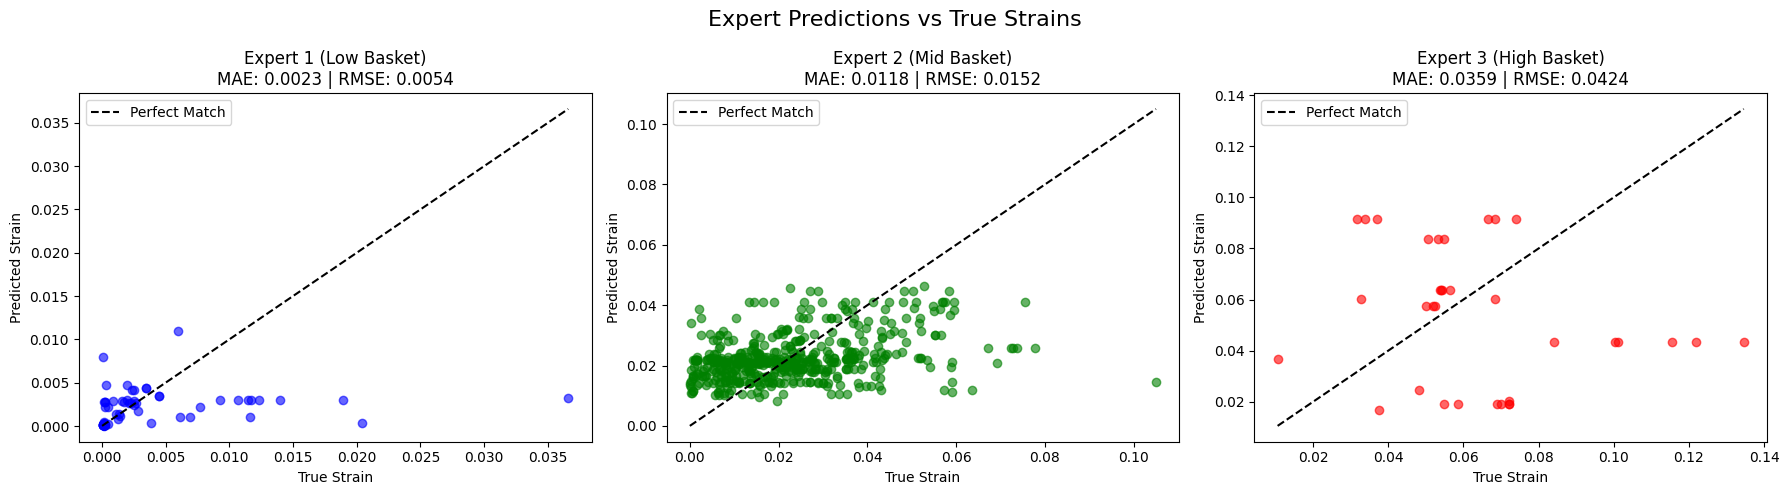

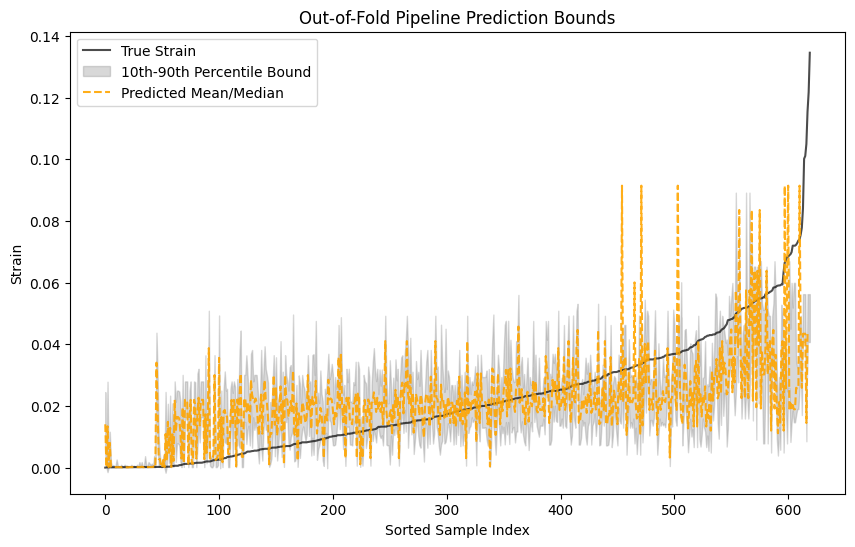

In [37]:
valid_mask = ~np.isnan(oof_predictions)

global_mae = mean_absolute_error(raw_df['Second Strain'][valid_mask], oof_predictions[valid_mask])
global_rmse = np.sqrt(mean_squared_error(raw_df['Second Strain'][valid_mask], oof_predictions[valid_mask]))

print(f"Global OOF Pipeline MAE:  {global_mae:.4f}")
print(f"Global OOF Pipeline RMSE: {global_rmse:.4f}")

raw_df['oof_pred'] = oof_predictions
raw_df['oof_pred_10'] = oof_bounds[:, 0]
raw_df['oof_pred_50_or_mean'] = oof_bounds[:, 1]
raw_df['oof_pred_90'] = oof_bounds[:, 2]
raw_df['assigned_basket'] = oof_baskets

# Visualizing Error per Expert
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Expert Predictions vs True Strains', fontsize=16)

colors = {0: 'blue', 1: 'green', 2: 'red'}
titles = {0: 'Expert 1 (Low Basket)', 1: 'Expert 2 (Mid Basket)', 2: 'Expert 3 (High Basket)'}

for basket_id in [0, 1, 2]:
    ax = axes[basket_id]
    basket_data = raw_df[(raw_df['assigned_basket'] == basket_id) & valid_mask]
    
    if len(basket_data) == 0:
        ax.set_title(f"{titles[basket_id]} - No Data")
        continue
        
    y_true = basket_data['Second Strain']
    y_pred = basket_data['oof_pred']
    
    ax.scatter(y_true, y_pred, alpha=0.6, color=colors[basket_id])
    
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=1.5, label='Perfect Match')
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    ax.set_title(f"{titles[basket_id]}\nMAE: {mae:.4f} | RMSE: {rmse:.4f}")
    ax.set_xlabel('True Strain')
    ax.set_ylabel('Predicted Strain')
    ax.legend()
    
plt.tight_layout()
plt.show()

# Visualizing Prediction Bounds
plt.figure(figsize=(10, 6))
sorted_idx = raw_df[valid_mask].sort_values('Second Strain').index
plt.plot(raw_df.loc[sorted_idx, 'Second Strain'].values, label='True Strain', color='black', alpha=0.7)
plt.fill_between(range(len(sorted_idx)), 
                 raw_df.loc[sorted_idx, 'oof_pred_10'].values, 
                 raw_df.loc[sorted_idx, 'oof_pred_90'].values, 
                 color='gray', alpha=0.3, label='10th-90th Percentile Bound')
plt.plot(raw_df.loc[sorted_idx, 'oof_pred'].values, label='Predicted Mean/Median', color='orange', alpha=0.9, linestyle='--')
plt.title('Out-of-Fold Pipeline Prediction Bounds')
plt.ylabel('Strain')
plt.xlabel('Sorted Sample Index')
plt.legend()
plt.show()

# Phase 6: Interpretability — SHAP Analysis & Mutual Information

Two interpretability lenses applied after all predictions are complete:

- **SHAP** (cell 16): re-trains the three expert models on the **full dataset** using the production router's soft weights, then runs `TreeExplainer` for both LGBM experts and the inner GBR. The TabPFN router gets a `KernelExplainer` pass on a 60-point sample (~2 min).
- **Mutual Information** (cell 17): reports MI between each feature and its region's target. Because `mutual_info_regression` has no `sample_weight` argument, each expert filters to rows where its routing probability exceeds a threshold before estimating MI.

Mutual Information Scores (raw nats):


,Expert 0 — Low,Expert 1 — Mid,Expert 2 — High,TabPFN Router
Fly ash F,0.3919,0.1959,0.0403,0.3838
Cement,0.4383,0.1619,0.0000,0.3635
W/C,0.4350,0.1526,0.1861,0.4625
Fiber Surface Area,0.1978,0.1361,0.0151,0.3829
L/D,0.4226,0.1263,0.0000,0.2436
W/B,0.5505,0.1250,0.0535,0.4083
sigma_cu_proxy,0.6080,0.1115,0.0202,0.4162
RI,0.1136,0.1087,0.0844,0.2658
Paste Volume,0.6186,0.1048,0.0141,0.3805
C/B,0.6208,0.1001,0.0243,0.3780


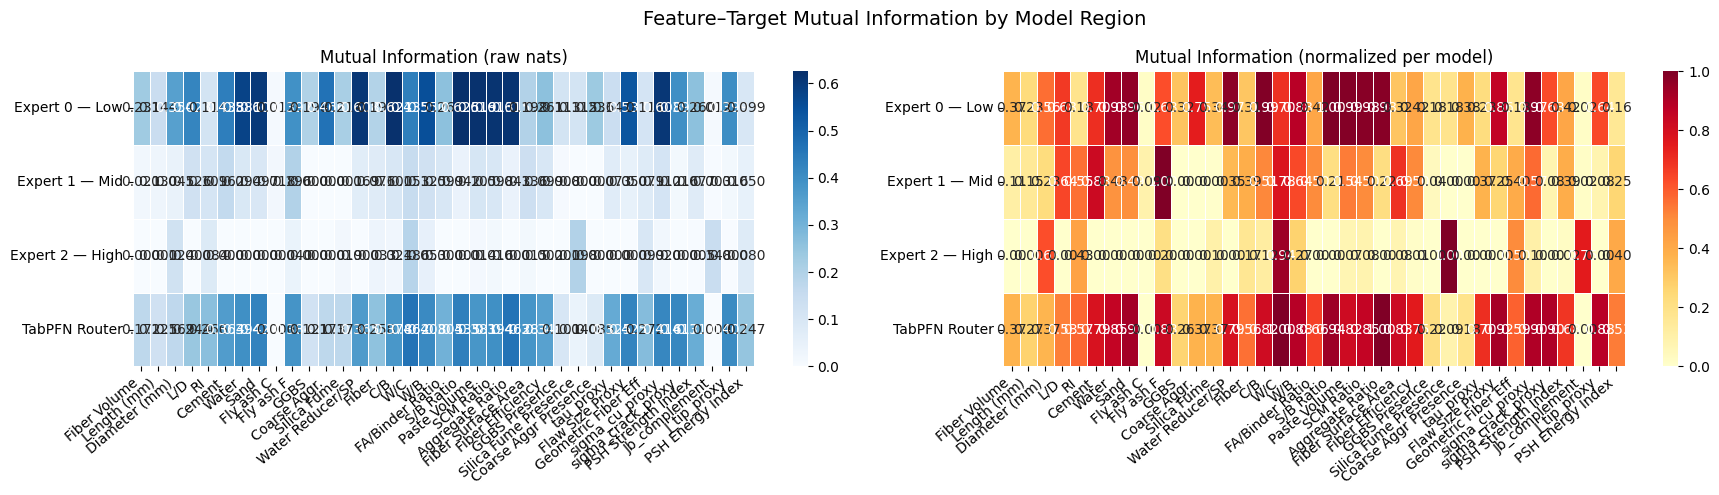


Top 5 features per model (MI rank):

  Expert 0 — Low:
    S/B Ratio            0.6254
    C/B                  0.6208
    Paste Volume         0.6186
    Aggregate Ratio      0.6149
    SCM Ratio            0.6134

  Expert 1 — Mid:
    Fly ash F            0.1959
    Cement               0.1619
    W/C                  0.1526
    Fiber Surface Area   0.1361
    L/D                  0.1263

  Expert 2 — High:
    Silica Fume Presence 0.1978
    W/C                  0.1861
    Jb_complement        0.1478
    Diameter (mm)        0.1238
    Geometric Fiber Eff  0.0994

  TabPFN Router:
    W/C                  0.4625
    Aggregate Ratio      0.4622
    S/B Ratio            0.4350
    Sand                 0.4275
    Flaw Size Proxy      0.4248


In [39]:
## 17. Mutual Information
# Requires the SHAP cell above to have been run (uses raw_for_shap, X_shap, y_shap).
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif

if not TABPFN_IS_WINNER or final_assignments is None:
    print('Skipping MI analysis: TabPFN was not the winning router.')
else:
    mi_data = {}

    # Per-expert MI: restrict to rows where that expert carries meaningful weight.
    # mutual_info_regression has no sample_weight param, so we use a prob threshold.
    for label, prob_col, threshold in [
        ('Expert 0 — Low',  'final_prob_low',  0.15),
        ('Expert 1 — Mid',  'final_prob_mid',  0.25),
        ('Expert 2 — High', 'final_prob_high', 0.10),
    ]:
        mask = raw_for_shap[prob_col].values > threshold
        if mask.sum() < 10:
            mask = np.ones(len(raw_for_shap), dtype=bool)
        mi = mutual_info_regression(X_shap[mask], y_shap.values[mask], random_state=RANDOM_STATE)
        mi_data[label] = pd.Series(mi, index=feature_columns)

    # Router MI: classification target (dominant_class_id)
    mi_router = mutual_info_classif(X, y, random_state=RANDOM_STATE)
    mi_data['TabPFN Router'] = pd.Series(mi_router, index=feature_columns)

    mi_df   = pd.DataFrame(mi_data)
    mi_norm = mi_df.divide(mi_df.max())

    print('Mutual Information Scores (raw nats):')
    display(mi_df.round(4).sort_values('Expert 1 — Mid', ascending=False))

    fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    sns.heatmap(mi_df.T, annot=True, fmt='.3f', cmap='Blues', linewidths=0.5,
                xticklabels=feature_columns, ax=axes[0])
    axes[0].set_title('Mutual Information (raw nats)', fontsize=12)
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=40, ha='right')

    sns.heatmap(mi_norm.T, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5,
                xticklabels=feature_columns, ax=axes[1])
    axes[1].set_title('Mutual Information (normalized per model)', fontsize=12)
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=40, ha='right')

    plt.suptitle('Feature–Target Mutual Information by Model Region', fontsize=14)
    plt.tight_layout()
    plt.show()

    print('\nTop 5 features per model (MI rank):')
    for col in mi_df.columns:
        top5 = mi_df[col].sort_values(ascending=False).head(5)
        print(f'\n  {col}:')
        for feat, score in top5.items():
            print(f'    {feat:<20} {score:.4f}')